In [1]:
import sys
from pathlib import Path

# Adiciona a pasta raiz do projeto ao caminho de busca do Python
sys.path.append(str(Path.cwd().parent)) # Ou use Path(__file__) se for script

import banco

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

conexao = banco.conectar()

# Os 5 órgãos com maior custo total?

In [ ]:
query_q1 = """
    SELECT nome_orgao_superior, 
    SUM(valor_total) AS custo_total
    FROM silver_viagem
    WHERE nome_orgao_superior IS NOT NULL
    GROUP BY nome_orgao_superior
    ORDER BY custo_total DESC
    LIMIT 5
"""

banco.executar(conexao, "DROP VIEW IF EXISTS gold_vw_orgaos_maior_custo")
banco.executar(conexao, "DROP TABLE IF EXISTS gold_orgaos_maior_custo")

banco.executar(conexao, f"CREATE VIEW gold_vw_orgaos_maior_custo AS {query_q1}")
banco.executar(conexao, f"CREATE TABLE gold_orgaos_maior_custo AS {query_q1}")

df_q1 = pd.read_sql(query_q1, conexao)
plt.figure(figsize=(10, 5))
sns.barplot(data=df_q1, y='nome_orgao_superior', x='custo_total', palette='Blues_r')
plt.title('Os 5 Órgãos com Maior Custo Total de Viagens', fontsize=14)
plt.xlabel('Custo Total')
plt.ylabel('Órgão Superior')
plt.show()

# Os 3 destinos com maior custo médio por viagem?

In [ ]:
query_q2 = """
    SELECT destinos, 
    AVG(valor_total) AS custo_medio
    FROM silver_viagem
    WHERE destinos IS NOT NULL AND destinos != ''
    GROUP BY destinos
    ORDER BY custo_medio DESC
    LIMIT 3
"""

banco.executar(conexao, "DROP VIEW IF EXISTS gold_vw_destinos_custo_medio")
banco.executar(conexao, "DROP TABLE IF EXISTS gold_destinos_custo_medio")

banco.executar(conexao, f"CREATE VIEW gold_vw_destinos_custo_medio AS {query_q2}")
banco.executar(conexao, f"CREATE TABLE gold_destinos_custo_medio AS {query_q2}")

df_q2 = pd.read_sql(query_q2, conexao)
plt.figure(figsize=(8, 4))
sns.barplot(data=df_q2, x='custo_medio', y='destinos', palette='Reds_r')
plt.title('Os 3 Destinos com Maior Custo Médio por Viagem', fontsize=14)
plt.xlabel('Custo Médio (R$)')
plt.ylabel('Destino')
plt.show()

# A viagem de maior duração e seu custo total?

In [ ]:
query_q3 = """
    SELECT id_viagem, destinos, duracao_dias, valor_total
    FROM silver_viagem
    WHERE duracao_dias IS NOT NULL
    ORDER BY duracao_dias DESC
    LIMIT 1
"""


banco.executar(conexao, "DROP VIEW IF EXISTS gold_vw_viagem_maior_duracao")
banco.executar(conexao, "DROP TABLE IF EXISTS gold_viagem_maior_duracao")

banco.executar(conexao, f"CREATE VIEW gold_vw_viagem_maior_duracao AS {query_q3}")
banco.executar(conexao, f"CREATE TABLE gold_viagem_maior_duracao AS {query_q3}")

df_q3 = pd.read_sql(query_q3, conexao)
plt.figure(figsize=(10, 5))
sns.barplot(data=df_q3, x='destinos', y='duracao_dias', palette='magma')
plt.title('Viagem de Maior Duração', fontsize=14)
plt.xlabel('Viagem para...')
plt.ylabel('Duração em Dias')

# Qual o tipo de pagamento com maior valor médio?

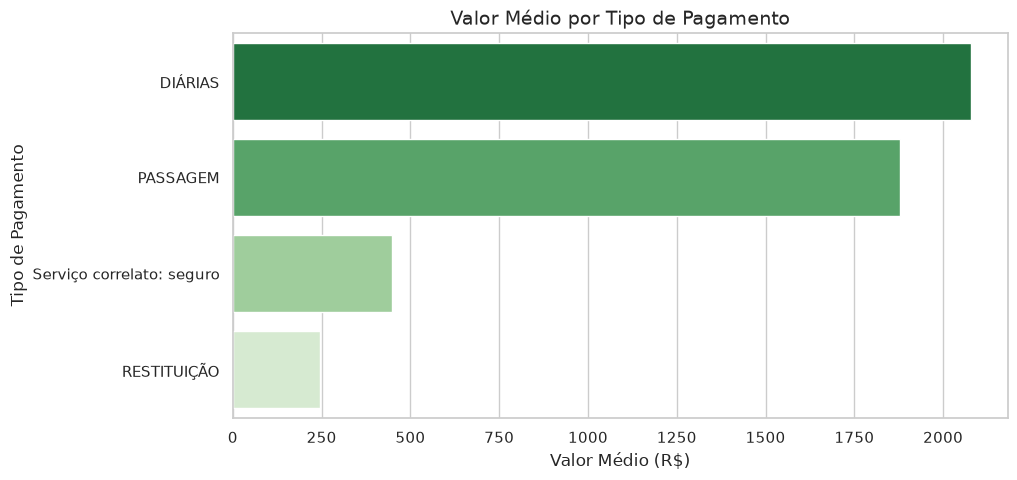

In [5]:
query_q4 = """
    SELECT tipo_pagamento, 
    AVG(valor) AS valor_medio
    FROM silver_pagamento
    WHERE tipo_pagamento IS NOT NULL
    GROUP BY tipo_pagamento
    ORDER BY valor_medio DESC
"""

banco.executar(conexao, "DROP VIEW IF EXISTS gold_vw_pagamento_valor_medio")
banco.executar(conexao, "DROP TABLE IF EXISTS gold_pagamento_valor_medio")

banco.executar(conexao, f"CREATE VIEW gold_vw_pagamento_valor_medio AS {query_q4}")
banco.executar(conexao, f"CREATE TABLE gold_pagamento_valor_medio AS {query_q4}")

df_q4 = pd.read_sql(query_q4, conexao)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_q4, x='valor_medio', y='tipo_pagamento', palette='Greens_r')
plt.title('Valor Médio por Tipo de Pagamento', fontsize=14)
plt.xlabel('Valor Médio (R$)')
plt.ylabel('Tipo de Pagamento')
plt.show()

# Qual o meio de transporte mais usado nos trechos?

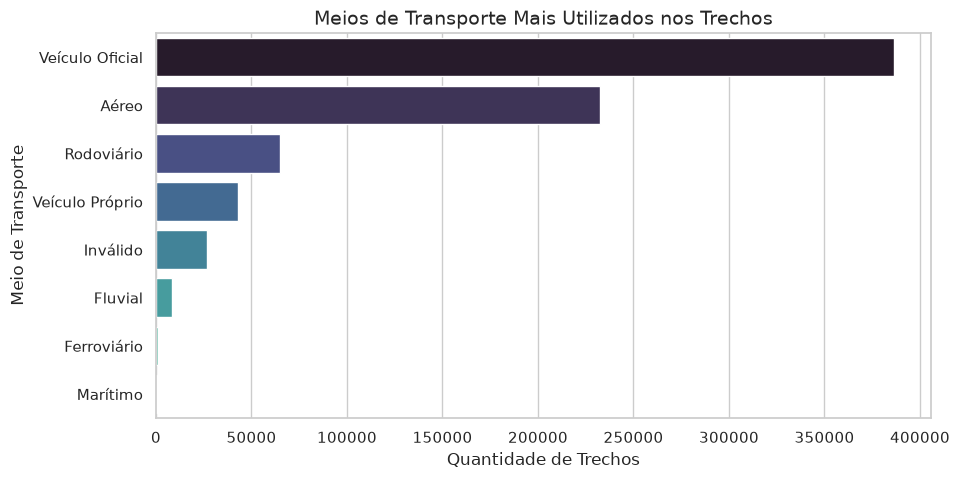

In [6]:
query_q5 = """
    SELECT 
        meio_transporte, 
        COUNT(id_trecho) AS qtd_trechos
    FROM silver_trecho
    WHERE meio_transporte IS NOT NULL
    GROUP BY meio_transporte
    ORDER BY qtd_trechos DESC
"""

banco.executar(conexao, "DROP VIEW IF EXISTS gold_vw_transporte_mais_usado")
banco.executar(conexao, f"CREATE VIEW gold_vw_transporte_mais_usado AS {query_q5}")

banco.executar(conexao, "DROP TABLE IF EXISTS gold_transporte_mais_usado")
banco.executar(conexao, f"CREATE TABLE gold_transporte_mais_usado AS {query_q5}")

df_q5 = pd.read_sql(query_q5, conexao)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_q5, x='qtd_trechos', y='meio_transporte', palette='mako')
plt.title('Meios de Transporte Mais Utilizados nos Trechos', fontsize=14)
plt.xlabel('Quantidade de Trechos')
plt.ylabel('Meio de Transporte')
plt.show()

# Qual UF de destino aparece em mais trechos?

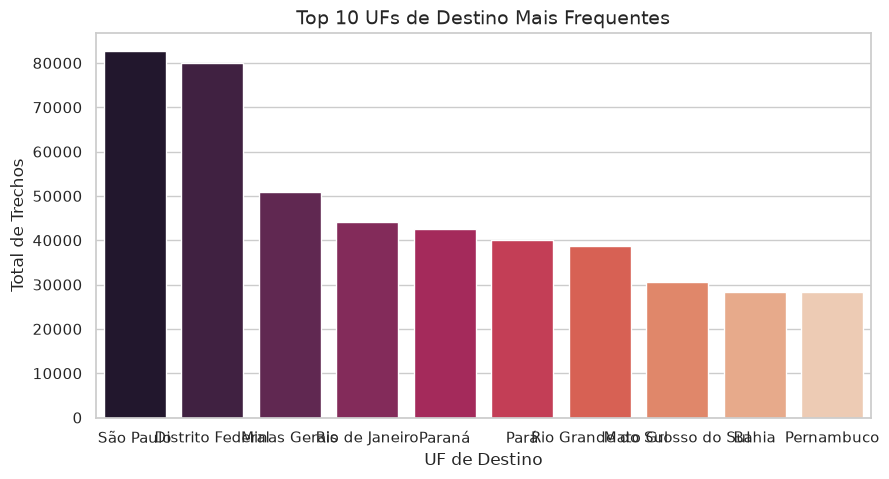

In [7]:
query_q6 = """
    SELECT 
        destino_uf, 
        COUNT(id_trecho) AS total_visitas
    FROM silver_trecho
    WHERE destino_uf IS NOT NULL AND destino_uf != ''
    GROUP BY destino_uf
    ORDER BY total_visitas DESC
    LIMIT 10
"""

banco.executar(conexao, "DROP VIEW IF EXISTS gold_vw_uf_destino_frequente")
banco.executar(conexao, f"CREATE VIEW gold_vw_uf_destino_frequente AS {query_q6}")

banco.executar(conexao, "DROP TABLE IF EXISTS gold_uf_destino_frequente")
banco.executar(conexao, f"CREATE TABLE gold_uf_destino_frequente AS {query_q6}")

df_q6 = pd.read_sql(query_q6, conexao)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_q6, x='destino_uf', y='total_visitas', palette='rocket')
plt.title('Top 10 UFs de Destino Mais Frequentes', fontsize=14)
plt.xlabel('UF de Destino')
plt.ylabel('Total de Trechos')
plt.show()